$\textbf{One-Port Optimized Calibration}$

imports 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from scipy import linalg,signal
from scipy.optimize import minimize
import metas_unclib as munc
import skrf as rf
from skrf.media import RectangularWaveguide
from SSS_opt import sss_opt

Definitions of Standards

In [2]:
#Initialize waveguide and standards


short_port1 = rf.Network('Wr28_160425/s1.s2p')['26-40GHz']
short_port2 = rf.Network('Wr28_160425/s2.s2p')['26-40GHz']

short_port1_l8 = rf.Network('Wr28_160425/sl8p1.s2p')['26-40GHz']
short_port1_l4 = rf.Network('Wr28_160425/sl4p1.s2p')['26-40GHz']
short_port1_3l8 = rf.Network('Wr28_160425/s3l8p1.s2p')['26-40GHz']

freq = short_port1.frequency
f = freq.f
ideal_short_rho = -1

WR28 = rf.RectangularWaveguide(freq,a=7.112E-3,z0=50 )
WR28_short = WR28.short()
rho1 = WR28.line(1.5494, 'mm')**WR28_short
rho2 = WR28.line(3.0734, 'mm')**WR28_short
rho3 = WR28.line(4.6228, 'mm')**WR28_short

In [3]:
#initialize E-Cal
unc_f = 10**(0.02/20)-1

print("Uncertainty Factor: ", unc_f)

cal = sss_opt(standard1=short_port1_l8, standard2=short_port1_l4, standard3=short_port1_3l8, rho1=rho1, rho2=rho2, rho3=rho3, 
                sigma_NF=10**(-80/20)*np.ones(len(freq)), sigma_NT=10**(0.001/20)-1*np.ones(len(freq)), sigma_L=10**(-80/20)*np.ones(len(freq)),
                sigma_DD=10**(-80/20)*np.ones(len(freq)), sigma_DT=10**(0.02/20)-1*np.ones(len(freq)), sigma_DM=10**(-80/20)*np.ones(len(freq)),
                sigma_RR=10**(-60/20)*np.ones(len(freq)), sigma_RT=0*np.ones(len(freq)), sigma_RM=0*np.ones(len(freq)),
                sigma_SR=10**(-40/20)*np.ones(len(freq)), conv_fact=3,
                enhanced_console_output=True, initial_guess=[1.2, 2.6, 4.3], ref_standard=short_port1, ref_standard_rho=WR28_short, Waveguide=WR28)

Uncertainty Factor:  0.0023052380778996184
Generating noise and linearity uncertainty matrix...
Generating drift uncertainty matrix...
Generating repeatability uncertainty matrix...
Generating standard uncertainty matrix...
Initialization complete.


In [ ]:
#run E-Calibration
cal.run()

[(0.05373645787812163-0.18164109832727762j) ± (0.11169667980586029+0.1116966798058603j)
 (0.051330929389880216-0.18308451648893592j) ± (0.11173609932309513+0.11173609932309514j)
 (0.04920116442163155-0.1847572043557261j) ± (0.11179158528839203+0.11179158528839202j)
 ...
 (0.003292366962587623-0.18527175678884694j) ± (0.06142100902743214+0.061421009027432145j)
 (0.004619515518448716-0.18522826930346542j) ± (0.06142325626412545+0.06142325626412545j)
 (0.0064032919601230915-0.18544673749403692j) ± (0.06142701147108118+0.06142701147108118j)]


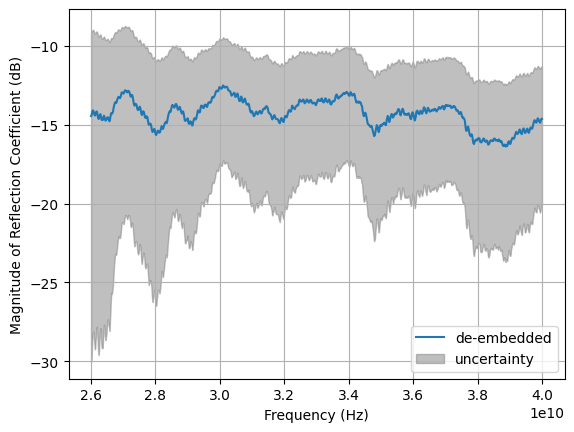

In [ ]:
thru = rf.Network('Wr28_160425/thru.s2p')['26-40GHz']
dut = cal.apply_cal(short_port2.s11)
print(dut)
plt.plot(f,(20*np.log10(np.abs(munc.get_value(dut)))), label='de-embedded')
plt.fill_between(f,(20*np.log10(np.abs(munc.get_value(dut))-np.abs(munc.get_stdunc(dut)))), (20*np.log10(np.abs(munc.get_value(dut))+np.abs(munc.get_stdunc(dut)))), color='grey', alpha=0.5, label='uncertainty')
plt.legend()
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude of Reflection Coefficient (dB)')
plt.grid()
plt.show()